In [1]:
!pip install rtdl_revisiting_models

In [4]:
#!/usr/bin/env python3
"""
Train an FT-Transformer model on Moltbook data using rtdl_revisiting_models.
Uses R² as the primary evaluation metric.
Optimized for large GPUs (A100) with memory efficiency.
"""
import os
# MUST be set before any CUDA operation to reduce fragmentation
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

# Import FTTransformer from the new package
from rtdl_revisiting_models import FTTransformer
from torch.cuda.amp import autocast, GradScaler
from torch.utils.data import TensorDataset, DataLoader

# ==========================================
# CONFIGURATION
# ==========================================
DESTINATION_DIR = '/content/drive/MyDrive/Colab Notebooks/data/cds'
DATA_PATH = f"{DESTINATION_DIR}/processed_v1_5_4_new_full.pkl"

EMBEDDING_COL = "embeddings"
TARGET_COL = "score"
RANDOM_STATE = 42
TEST_SIZE = 0.30
VAL_SIZE_FROM_TEMP = 0.50
DROP_COLS = ["safe_content", "content", "id"]



# GPU configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Total GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    torch.backends.cudnn.benchmark = True

# ==========================================
# 1. Load and prepare data
# ==========================================
print("Loading data...")
moltbook = pd.read_pickle(DATA_PATH)
print(f"Original shape: {moltbook.shape}")

# Expand embeddings
embedding_lists = moltbook[EMBEDDING_COL].values
lengths = [len(lst) for lst in embedding_lists]
if len(set(lengths)) != 1:
    raise ValueError("Embedding lists have varying lengths.")
emb_dim = lengths[0]
print(f"Embedding dimension: {emb_dim}")

emb_df = pd.DataFrame(
    np.vstack(embedding_lists),
    index=moltbook.index,
    columns=[f"emb_{i}" for i in range(emb_dim)]
)

# Base features - KEEP ONLY SPECIFIED FEATURES
# First, check which kept features are actually in the data

# KEPT_FEATURES = [
#     "comment_existence",
#     "max_early_sentiment", 
#     "avg_early_sentiment",
#     "min_early_sentiment",
#     "punctuation_density",
#     "ttr",
#     "hour",
#     "has_biological_tax",
#     "has_lobster",
#     "has_great_lobster"
# ]

# available_features = [f for f in KEPT_FEATURES if f in moltbook.columns]


# print(f"Keeping {len(available_features)} non-embedding features: {available_features}")

# # Select only the kept features (plus any that might be needed but not in the list)
# X_base = moltbook[available_features].copy()
X_base = moltbook.drop(columns=[TARGET_COL, EMBEDDING_COL] + DROP_COLS)
# Target and preprocessing
y_raw = moltbook[TARGET_COL].clip(lower=0)
y = np.log1p(y_raw)  # log-transform target

# Train/val/test split
X_base_train, X_base_temp, emb_train, emb_temp, y_train, y_temp = train_test_split(
    X_base, emb_df, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
X_base_val, X_base_test, emb_val, emb_test, y_val, y_test = train_test_split(
    X_base_temp, emb_temp, y_temp, test_size=VAL_SIZE_FROM_TEMP, random_state=RANDOM_STATE
)

X_train = pd.concat([X_base_train, emb_train], axis=1)
X_val   = pd.concat([X_base_val, emb_val], axis=1)
X_test  = pd.concat([X_base_test, emb_test], axis=1)

print(f"Training set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set: {X_test.shape}")

# # Print feature statistics to verify
# print("\nNon-embedding features included:")
# for feature in available_features:
#     print(f"  - {feature}")

# ==========================================
# Convert to PyTorch tensors (keep on CPU initially)
# ==========================================
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
X_val_tensor   = torch.tensor(X_val.values, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).reshape(-1, 1)
y_val_tensor   = torch.tensor(y_val.values, dtype=torch.float32).reshape(-1, 1)
y_test_tensor  = torch.tensor(y_test.values, dtype=torch.float32).reshape(-1, 1)

# ==========================================
# Create DataLoaders 
# ==========================================
batch_size = 64          
num_workers = 0           

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset   = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset  = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                          pin_memory=True, num_workers=num_workers)
val_loader   = DataLoader(val_dataset, batch_size=batch_size*2, shuffle=False,
                          pin_memory=True, num_workers=num_workers)
test_loader  = DataLoader(test_dataset, batch_size=batch_size*2, shuffle=False,
                          pin_memory=True, num_workers=num_workers)

# ==========================================
# 2. Define FT-Transformer model
# ==========================================
print("\nInitializing FT-Transformer model...")
n_num_features = X_train.shape[1]  # All features are numerical
d_out = 1

# Get default config and optionally reduce model size (uncomment if needed)
default_kwargs = FTTransformer.get_default_kwargs()
# --- Optional: reduce model size for lower memory ---
# default_kwargs.update({
#     'n_blocks': 3,          # default is usually 6
#     'd_token': 192,         # default 384
#     'attention_n_heads': 4, # default 8
#     'ffn_d_factor': 2,      # default 4/3
# })
# ----------------------------------------------------

model = FTTransformer(
    n_cont_features=n_num_features,
    cat_cardinalities=None,
    d_out=d_out,
    **default_kwargs,
)

print(f"Model has {sum(p.numel() for p in model.parameters() if p.requires_grad):,} trainable parameters")
print(f"Total input features: {n_num_features} (8 non-embedding + {emb_dim} embedding dimensions)")
model = model.to(device)

# ==========================================
# 3. Training setup
# ==========================================
optimizer = model.make_default_optimizer()
criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

# Mixed precision scaler
scaler = GradScaler()

n_epochs = 500
patience = 50
best_val_loss = float('inf')
best_model_state = None
patience_counter = 0

# ==========================================
# 4. Training loop with mixed precision and batch-level GPU transfers
# ==========================================
print("\nStarting training...")

for epoch in range(n_epochs):
    model.train()
    epoch_loss = 0.0

    for X_batch, y_batch in train_loader:
        # Move batch to GPU (non_blocking for overlap)
        X_batch = X_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)

        optimizer.zero_grad()

        # Mixed precision forward
        with autocast():
            predictions = model(X_batch, None)
            loss = criterion(predictions, y_batch)

        # Backward with gradient scaling
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)                     # for gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item() * X_batch.size(0)

    epoch_loss /= len(train_loader.dataset)

    # ---------- Validation ----------
    model.eval()
    val_loss = 0.0
    all_preds = []
    all_y = []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)
            with autocast():
                preds = model(X_batch, None)
                loss = criterion(preds, y_batch)
            val_loss += loss.item() * X_batch.size(0)
            all_preds.append(preds.cpu())
            all_y.append(y_batch.cpu())

    val_loss /= len(val_loader.dataset)
    val_preds = torch.cat(all_preds).numpy()
    val_true = torch.cat(all_y).numpy()
    val_r2 = r2_score(val_true, val_preds)

    scheduler.step(val_loss)

    if (epoch + 1) % 20 == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1}/{n_epochs} | Train Loss: {epoch_loss:.6f} | "
              f"Val Loss: {val_loss:.6f} | Val R²: {val_r2:.4f} | LR: {current_lr:.2e}")
        if device.type == "cuda":
            allocated = torch.cuda.memory_allocated(0) / 1e9
            reserved = torch.cuda.memory_reserved(0) / 1e9
            print(f"  GPU Memory: {allocated:.2f} GB allocated, {reserved:.2f} GB reserved")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch+1}")
            break

# Load best model
model.load_state_dict({k: v.to(device) for k, v in best_model_state.items()})

# ==========================================
# 5. Final evaluation on test set
# ==========================================
model.eval()
test_loss = 0.0
all_test_preds = []
all_test_y = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)
        with autocast():
            preds = model(X_batch, None)
            loss = criterion(preds, y_batch)
        test_loss += loss.item() * X_batch.size(0)
        all_test_preds.append(preds.cpu())
        all_test_y.append(y_batch.cpu())

test_loss /= len(test_loader.dataset)
test_preds = torch.cat(all_test_preds).numpy()
test_true = torch.cat(all_test_y).numpy()
test_r2 = r2_score(test_true, test_preds)

# Also compute final validation R² using the best model
val_loss_final = 0.0
all_val_preds = []
all_val_y = []
with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)
        with autocast():
            preds = model(X_batch, None)
        all_val_preds.append(preds.cpu())
        all_val_y.append(y_batch.cpu())
val_preds_final = torch.cat(all_val_preds).numpy()
val_true_final = torch.cat(all_val_y).numpy()
val_r2_final = r2_score(val_true_final, val_preds_final)

print("\n" + "="*50)
print("FINAL RESULTS")
print("="*50)
print(f"Validation R²: {val_r2_final:.4f}")
print(f"Test R²: {test_r2:.4f}")
print(f"Test MSE: {test_loss:.6f}")

# Clear cache before feature importance (optional)
torch.cuda.empty_cache()

# ==========================================
# 7. Save model and results
# ==========================================
# model_info = {
#     'model_state_dict': {k: v.cpu() for k, v in best_model_state.items()},
#     'model_config': {
#         'n_cont_features': n_num_features,
#         'cat_cardinalities': None,
#         'd_out': d_out,
#         'default_kwargs': default_kwargs,
#     },
#     'feature_names': list(X_train.columns),
#     'kept_non_embedding_features': available_features,
#     'device_info': str(device)
# }
# torch.save(model_info, 'ft_transformer_model.pth')
# print("\nModel saved as 'ft_transformer_model.pth'")

# results = {
#     'r2_validation': val_r2_final,
#     'r2_test': test_r2,
#     'test_mse': test_loss,
#     'kept_features': available_features,
#     'total_features': n_num_features,
#     'embedding_dim': emb_dim,
#     'device_used': str(device)
# }
# joblib.dump(results, 'ft_transformer_results.pkl')
# print("Results saved as 'ft_transformer_results.pkl'")

# Final cleanup
if device.type == "cuda":
    torch.cuda.empty_cache()
    print(f"Final GPU memory allocated: {torch.cuda.memory_allocated(0)/1e9:.2f} GB")

print("\nTraining complete!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda
GPU: NVIDIA A100-SXM4-40GB
Total GPU memory: 42.41 GB
Loading data...
Original shape: (20287, 20)
Embedding dimension: 768
Training set: (14200, 783)
Validation set: (3043, 783)
Test set: (3044, 783)

Initializing FT-Transformer model...
Model has 1,192,513 trainable parameters
Total input features: 783 (8 non-embedding + 768 embedding dimensions)

Starting training...
Epoch 20/500 | Train Loss: 0.373239 | Val Loss: 0.403430 | Val R²: 0.2844 | LR: 1.00e-04
  GPU Memory: 0.04 GB allocated, 9.08 GB reserved
Epoch 40/500 | Train Loss: 0.323210 | Val Loss: 0.443460 | Val R²: 0.2134 | LR: 1.00e-04
  GPU Memory: 0.04 GB allocated, 9.08 GB reserved
Epoch 60/500 | Train Loss: 0.272634 | Val Loss: 0.368040 | Val R²: 0.3472 | LR: 2.50e-05
  GPU Memory: 0.04 GB allocated, 9.08 GB reserved
Epoch 80/500 | Train Loss: 0.253142 | Val Loss: 0.372992 | Val 

In [11]:
#!/usr/bin/env python3
"""
Train an FT-Transformer model on Moltbook data using rtdl_revisiting_models.
Uses R² as the primary evaluation metric.
Optimized for large GPUs (A100) with memory efficiency.
"""
import os
# MUST be set before any CUDA operation to reduce fragmentation
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

# Import FTTransformer from the new package
from rtdl_revisiting_models import FTTransformer
from torch.cuda.amp import autocast, GradScaler
from torch.utils.data import TensorDataset, DataLoader

# ==========================================
# CONFIGURATION
# ==========================================
DESTINATION_DIR = '/content/drive/MyDrive/Colab Notebooks/data/cds'
DATA_PATH = f"{DESTINATION_DIR}/processed_v1_5_4_new_full.pkl"

EMBEDDING_COL = "embeddings"
TARGET_COL = "score"
RANDOM_STATE = 42
TEST_SIZE = 0.30
VAL_SIZE_FROM_TEMP = 0.50
DROP_COLS = ["safe_content", "content", "id"]

# GPU configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Total GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    torch.backends.cudnn.benchmark = True

# ==========================================
# 1. Load and prepare data
# ==========================================
print("Loading data...")
moltbook = pd.read_pickle(DATA_PATH)
print(f"Original shape: {moltbook.shape}")

# Expand embeddings
embedding_lists = moltbook[EMBEDDING_COL].values
lengths = [len(lst) for lst in embedding_lists]
if len(set(lengths)) != 1:
    raise ValueError("Embedding lists have varying lengths.")
emb_dim = lengths[0]
print(f"Embedding dimension: {emb_dim}")

emb_df = pd.DataFrame(
    np.vstack(embedding_lists),
    index=moltbook.index,
    columns=[f"emb_{i}" for i in range(emb_dim)]
)

# Base features
X_base = moltbook.drop(columns=[TARGET_COL, EMBEDDING_COL] + DROP_COLS)

# Target and preprocessing
y_raw = moltbook[TARGET_COL].clip(lower=0)
y = np.log1p(y_raw)  # log-transform target

# Train/val/test split
X_base_train, X_base_temp, emb_train, emb_temp, y_train, y_temp = train_test_split(
    X_base, emb_df, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
X_base_val, X_base_test, emb_val, emb_test, y_val, y_test = train_test_split(
    X_base_temp, emb_temp, y_temp, test_size=VAL_SIZE_FROM_TEMP, random_state=RANDOM_STATE
)

# ==========================================
# Apply StandardScaler
# ==========================================
print("\nApplying StandardScaler...")

# Initialize scalers
scaler_X_base = StandardScaler()
scaler_emb = StandardScaler()

# Fit scalers on training data only
X_base_train_scaled = scaler_X_base.fit_transform(X_base_train)
emb_train_scaled = scaler_emb.fit_transform(emb_train)

# Transform validation and test data
X_base_val_scaled = scaler_X_base.transform(X_base_val)
emb_val_scaled = scaler_emb.transform(emb_val)

X_base_test_scaled = scaler_X_base.transform(X_base_test)
emb_test_scaled = scaler_emb.transform(emb_test)

# Convert back to DataFrame to preserve column names
X_base_train_scaled = pd.DataFrame(X_base_train_scaled, 
                                   columns=X_base_train.columns, 
                                   index=X_base_train.index)
emb_train_scaled = pd.DataFrame(emb_train_scaled, 
                                columns=emb_train.columns, 
                                index=emb_train.index)

X_base_val_scaled = pd.DataFrame(X_base_val_scaled, 
                                 columns=X_base_val.columns, 
                                 index=X_base_val.index)
emb_val_scaled = pd.DataFrame(emb_val_scaled, 
                              columns=emb_val.columns, 
                              index=emb_val.index)

X_base_test_scaled = pd.DataFrame(X_base_test_scaled, 
                                  columns=X_base_test.columns, 
                                  index=X_base_test.index)
emb_test_scaled = pd.DataFrame(emb_test_scaled, 
                               columns=emb_test.columns, 
                               index=emb_test.index)

# Combine scaled features
X_train = pd.concat([X_base_train_scaled, emb_train_scaled], axis=1)
X_val = pd.concat([X_base_val_scaled, emb_val_scaled], axis=1)
X_test = pd.concat([X_base_test_scaled, emb_test_scaled], axis=1)

print(f"Training set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set: {X_test.shape}")

# Print scaling statistics
print("\nScaling statistics:")
print(f"Base features - Mean range: [{scaler_X_base.mean_.min():.3f}, {scaler_X_base.mean_.max():.3f}]")
print(f"Base features - Std range: [{scaler_X_base.scale_.min():.3f}, {scaler_X_base.scale_.max():.3f}]")
print(f"Embeddings - Mean range: [{scaler_emb.mean_.min():.3f}, {scaler_emb.mean_.max():.3f}]")
print(f"Embeddings - Std range: [{scaler_emb.scale_.min():.3f}, {scaler_emb.scale_.max():.3f}]")

# ==========================================
# Convert to PyTorch tensors (keep on CPU initially)
# ==========================================
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).reshape(-1, 1)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).reshape(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).reshape(-1, 1)

# ==========================================
# Create DataLoaders (move batches to GPU on the fly)
# ==========================================
batch_size = 64
num_workers = 0

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                          pin_memory=True, num_workers=num_workers)
val_loader = DataLoader(val_dataset, batch_size=batch_size*2, shuffle=False,
                        pin_memory=True, num_workers=num_workers)
test_loader = DataLoader(test_dataset, batch_size=batch_size*2, shuffle=False,
                         pin_memory=True, num_workers=num_workers)

# ==========================================
# 2. Define FT-Transformer model
# ==========================================
print("\nInitializing FT-Transformer model...")
n_num_features = X_train.shape[1]  # All features are numerical
d_out = 1

# Get default config
default_kwargs = FTTransformer.get_default_kwargs()

model = FTTransformer(
    n_cont_features=n_num_features,
    cat_cardinalities=None,
    d_out=d_out,
    **default_kwargs,
)

print(f"Model has {sum(p.numel() for p in model.parameters() if p.requires_grad):,} trainable parameters")
print(f"Total input features: {n_num_features} ({X_base.shape[1]} non-embedding + {emb_dim} embedding dimensions)")
model = model.to(device)

# ==========================================
# 3. Training setup
# ==========================================
optimizer = model.make_default_optimizer()
criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

# Mixed precision scaler
scaler = GradScaler()

n_epochs = 500
patience = 50
best_val_loss = float('inf')
best_model_state = None
patience_counter = 0

# ==========================================
# 4. Training loop with mixed precision and batch-level GPU transfers
# ==========================================
print("\nStarting training...")

for epoch in range(n_epochs):
    model.train()
    epoch_loss = 0.0

    for X_batch, y_batch in train_loader:
        # Move batch to GPU (non_blocking for overlap)
        X_batch = X_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)

        optimizer.zero_grad()

        # Mixed precision forward
        with autocast():
            predictions = model(X_batch, None)
            loss = criterion(predictions, y_batch)

        # Backward with gradient scaling
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)                     # for gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item() * X_batch.size(0)

    epoch_loss /= len(train_loader.dataset)

    # ---------- Validation ----------
    model.eval()
    val_loss = 0.0
    all_preds = []
    all_y = []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)
            with autocast():
                preds = model(X_batch, None)
                loss = criterion(preds, y_batch)
            val_loss += loss.item() * X_batch.size(0)
            all_preds.append(preds.cpu())
            all_y.append(y_batch.cpu())

    val_loss /= len(val_loader.dataset)
    val_preds = torch.cat(all_preds).numpy()
    val_true = torch.cat(all_y).numpy()
    val_r2 = r2_score(val_true, val_preds)

    scheduler.step(val_loss)

    if (epoch + 1) % 20 == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1}/{n_epochs} | Train Loss: {epoch_loss:.6f} | "
              f"Val Loss: {val_loss:.6f} | Val R²: {val_r2:.4f} | LR: {current_lr:.2e}")
        if device.type == "cuda":
            allocated = torch.cuda.memory_allocated(0) / 1e9
            reserved = torch.cuda.memory_reserved(0) / 1e9
            print(f"  GPU Memory: {allocated:.2f} GB allocated, {reserved:.2f} GB reserved")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch+1}")
            break

# Load best model
model.load_state_dict({k: v.to(device) for k, v in best_model_state.items()})

# ==========================================
# 5. Final evaluation on test set
# ==========================================
model.eval()
test_loss = 0.0
all_test_preds = []
all_test_y = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)
        with autocast():
            preds = model(X_batch, None)
            loss = criterion(preds, y_batch)
        test_loss += loss.item() * X_batch.size(0)
        all_test_preds.append(preds.cpu())
        all_test_y.append(y_batch.cpu())

test_loss /= len(test_loader.dataset)
test_preds = torch.cat(all_test_preds).numpy()
test_true = torch.cat(all_test_y).numpy()
test_r2 = r2_score(test_true, test_preds)

# Also compute final validation R² using the best model
val_loss_final = 0.0
all_val_preds = []
all_val_y = []
with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)
        with autocast():
            preds = model(X_batch, None)
        all_val_preds.append(preds.cpu())
        all_val_y.append(y_batch.cpu())
val_preds_final = torch.cat(all_val_preds).numpy()
val_true_final = torch.cat(all_val_y).numpy()
val_r2_final = r2_score(val_true_final, val_preds_final)

print("\n" + "="*50)
print("FINAL RESULTS")
print("="*50)
print(f"Validation R²: {val_r2_final:.4f}")
print(f"Test R²: {test_r2:.4f}")
print(f"Test MSE: {test_loss:.6f}")

# Clear cache
torch.cuda.empty_cache()

# ==========================================
# 6. Save model, scalers, and results
# ==========================================
# Save scalers for future use
scaler_info = {
    'scaler_X_base': scaler_X_base,
    'scaler_emb': scaler_emb,
    'feature_names_base': list(X_base.columns),
    'feature_names_emb': list(emb_df.columns),
}
joblib.dump(scaler_info, 'ft_transformer_scalers.pkl')
print("\nScalers saved as 'ft_transformer_scalers.pkl'")

# Save model (commented out as in original)
# model_info = {
#     'model_state_dict': {k: v.cpu() for k, v in best_model_state.items()},
#     'model_config': {
#         'n_cont_features': n_num_features,
#         'cat_cardinalities': None,
#         'd_out': d_out,
#         'default_kwargs': default_kwargs,
#     },
#     'feature_names': list(X_train.columns),
#     'scaler_info': {
#         'X_base_mean': scaler_X_base.mean_,
#         'X_base_scale': scaler_X_base.scale_,
#         'emb_mean': scaler_emb.mean_,
#         'emb_scale': scaler_emb.scale_,
#     },
#     'device_info': str(device)
# }
# torch.save(model_info, 'ft_transformer_model.pth')
# print("Model saved as 'ft_transformer_model.pth'")

# results = {
#     'r2_validation': val_r2_final,
#     'r2_test': test_r2,
#     'test_mse': test_loss,
#     'total_features': n_num_features,
#     'embedding_dim': emb_dim,
#     'device_used': str(device)
# }
# joblib.dump(results, 'ft_transformer_results.pkl')
# print("Results saved as 'ft_transformer_results.pkl'")

# Final cleanup
if device.type == "cuda":
    torch.cuda.empty_cache()
    print(f"Final GPU memory allocated: {torch.cuda.memory_allocated(0)/1e9:.2f} GB")

print("\nTraining complete!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda
GPU: NVIDIA A100-SXM4-40GB
Total GPU memory: 42.41 GB
Loading data...
Original shape: (20287, 20)
Embedding dimension: 768

Applying StandardScaler...
Training set: (14200, 783)
Validation set: (3043, 783)
Test set: (3044, 783)

Scaling statistics:
Base features - Mean range: [-0.058, 11.645]
Base features - Std range: [0.028, 6.946]
Embeddings - Mean range: [-3.510, 0.725]
Embeddings - Std range: [0.107, 0.605]

Initializing FT-Transformer model...
Model has 1,192,513 trainable parameters
Total input features: 783 (15 non-embedding + 768 embedding dimensions)

Starting training...
Epoch 20/500 | Train Loss: 0.287134 | Val Loss: 0.416716 | Val R²: 0.2608 | LR: 1.00e-04
  GPU Memory: 0.11 GB allocated, 9.19 GB reserved
Epoch 40/500 | Train Loss: 0.221556 | Val Loss: 0.390743 | Val R²: 0.3069 | LR: 2.50e-05
  GPU Memory: 0.11 GB allocated, 9.

In [10]:
#!/usr/bin/env python3
"""
Train an FT-Transformer model on Moltbook data using rtdl_revisiting_models.
Uses R² as the primary evaluation metric.
Optimized for large GPUs (A100) with memory efficiency.
"""
import os
# MUST be set before any CUDA operation to reduce fragmentation
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

# Import FTTransformer from the new package
from rtdl_revisiting_models import FTTransformer
from torch.cuda.amp import autocast, GradScaler
from torch.utils.data import TensorDataset, DataLoader

# ==========================================
# CONFIGURATION
# ==========================================
DESTINATION_DIR = '/content/drive/MyDrive/Colab Notebooks/data/cds'
DATA_PATH = f"{DESTINATION_DIR}/moltbook_with_keyword_features.pkl"

EMBEDDING_COL = "embeddings"
TARGET_COL = "score"
RANDOM_STATE = 42
TEST_SIZE = 0.30
VAL_SIZE_FROM_TEMP = 0.50
DROP_COLS = ["safe_content", "content", "id"]

# List of features to keep (from your feature importance analysis)


# GPU configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Total GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    torch.backends.cudnn.benchmark = True

# ==========================================
# 1. Load and prepare data
# ==========================================
print("Loading data...")
moltbook = pd.read_pickle(DATA_PATH)
print(f"Original shape: {moltbook.shape}")

# Expand embeddings
embedding_lists = moltbook[EMBEDDING_COL].values
lengths = [len(lst) for lst in embedding_lists]
if len(set(lengths)) != 1:
    raise ValueError("Embedding lists have varying lengths.")
emb_dim = lengths[0]
print(f"Embedding dimension: {emb_dim}")

emb_df = pd.DataFrame(
    np.vstack(embedding_lists),
    index=moltbook.index,
    columns=[f"emb_{i}" for i in range(emb_dim)]
)

# Base features - KEEP ONLY SPECIFIED FEATURES
# First, check which kept features are actually in the data

KEPT_FEATURES = [
    "comment_existence",
    "max_early_sentiment", 
    "avg_early_sentiment",
    "min_early_sentiment",
    "punctuation_density",
    "ttr",
    "hour",
    "has_biological_tax",
    "has_lobster",
    "has_great_lobster"
]

available_features = [f for f in KEPT_FEATURES if f in moltbook.columns]


print(f"Keeping {len(available_features)} non-embedding features: {available_features}")

# Select only the kept features (plus any that might be needed but not in the list)
X_base = moltbook[available_features].copy()
# X_base = moltbook.drop(columns=[TARGET_COL, EMBEDDING_COL] + DROP_COLS)
# Target and preprocessing
y_raw = moltbook[TARGET_COL].clip(lower=0)
y = np.log1p(y_raw)  # log-transform target

# Train/val/test split
X_base_train, X_base_temp, emb_train, emb_temp, y_train, y_temp = train_test_split(
    X_base, emb_df, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
X_base_val, X_base_test, emb_val, emb_test, y_val, y_test = train_test_split(
    X_base_temp, emb_temp, y_temp, test_size=VAL_SIZE_FROM_TEMP, random_state=RANDOM_STATE
)

X_train = pd.concat([X_base_train, emb_train], axis=1)
X_val   = pd.concat([X_base_val, emb_val], axis=1)
X_test  = pd.concat([X_base_test, emb_test], axis=1)

print(f"Training set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set: {X_test.shape}")

# Print feature statistics to verify
print("\nNon-embedding features included:")
for feature in available_features:
    print(f"  - {feature}")

# ==========================================
# Convert to PyTorch tensors (keep on CPU initially)
# ==========================================
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
X_val_tensor   = torch.tensor(X_val.values, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).reshape(-1, 1)
y_val_tensor   = torch.tensor(y_val.values, dtype=torch.float32).reshape(-1, 1)
y_test_tensor  = torch.tensor(y_test.values, dtype=torch.float32).reshape(-1, 1)

# ==========================================
# Create DataLoaders 
# ==========================================
batch_size = 64         
num_workers = 0         

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset   = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset  = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                          pin_memory=True, num_workers=num_workers)
val_loader   = DataLoader(val_dataset, batch_size=batch_size*2, shuffle=False,
                          pin_memory=True, num_workers=num_workers)
test_loader  = DataLoader(test_dataset, batch_size=batch_size*2, shuffle=False,
                          pin_memory=True, num_workers=num_workers)

# ==========================================
# 2. Define FT-Transformer model
# ==========================================
print("\nInitializing FT-Transformer model...")
n_num_features = X_train.shape[1]  # All features are numerical
d_out = 1

# Get default config and optionally reduce model size (uncomment if needed)
default_kwargs = FTTransformer.get_default_kwargs()
# --- Optional: reduce model size for lower memory ---
# default_kwargs.update({
#     'n_blocks': 3,          # default is usually 6
#     'd_token': 192,         # default 384
#     'attention_n_heads': 4, # default 8
#     'ffn_d_factor': 2,      # default 4/3
# })
# ----------------------------------------------------

model = FTTransformer(
    n_cont_features=n_num_features,
    cat_cardinalities=None,
    d_out=d_out,
    **default_kwargs,
)

print(f"Model has {sum(p.numel() for p in model.parameters() if p.requires_grad):,} trainable parameters")
print(f"Total input features: {n_num_features} (8 non-embedding + {emb_dim} embedding dimensions)")
model = model.to(device)

# ==========================================
# 3. Training setup
# ==========================================
optimizer = model.make_default_optimizer()
criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

# Mixed precision scaler
scaler = GradScaler()

n_epochs = 500
patience = 50
best_val_loss = float('inf')
best_model_state = None
patience_counter = 0

# ==========================================
# 4. Training loop with mixed precision and batch-level GPU transfers
# ==========================================
print("\nStarting training...")

for epoch in range(n_epochs):
    model.train()
    epoch_loss = 0.0

    for X_batch, y_batch in train_loader:
        # Move batch to GPU (non_blocking for overlap)
        X_batch = X_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)

        optimizer.zero_grad()

        # Mixed precision forward
        with autocast():
            predictions = model(X_batch, None)
            loss = criterion(predictions, y_batch)

        # Backward with gradient scaling
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)                     # for gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item() * X_batch.size(0)

    epoch_loss /= len(train_loader.dataset)

    # ---------- Validation ----------
    model.eval()
    val_loss = 0.0
    all_preds = []
    all_y = []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)
            with autocast():
                preds = model(X_batch, None)
                loss = criterion(preds, y_batch)
            val_loss += loss.item() * X_batch.size(0)
            all_preds.append(preds.cpu())
            all_y.append(y_batch.cpu())

    val_loss /= len(val_loader.dataset)
    val_preds = torch.cat(all_preds).numpy()
    val_true = torch.cat(all_y).numpy()
    val_r2 = r2_score(val_true, val_preds)

    scheduler.step(val_loss)

    if (epoch + 1) % 20 == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1}/{n_epochs} | Train Loss: {epoch_loss:.6f} | "
              f"Val Loss: {val_loss:.6f} | Val R²: {val_r2:.4f} | LR: {current_lr:.2e}")
        if device.type == "cuda":
            allocated = torch.cuda.memory_allocated(0) / 1e9
            reserved = torch.cuda.memory_reserved(0) / 1e9
            print(f"  GPU Memory: {allocated:.2f} GB allocated, {reserved:.2f} GB reserved")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch+1}")
            break

# Load best model
model.load_state_dict({k: v.to(device) for k, v in best_model_state.items()})

# ==========================================
# 5. Final evaluation on test set
# ==========================================
model.eval()
test_loss = 0.0
all_test_preds = []
all_test_y = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)
        with autocast():
            preds = model(X_batch, None)
            loss = criterion(preds, y_batch)
        test_loss += loss.item() * X_batch.size(0)
        all_test_preds.append(preds.cpu())
        all_test_y.append(y_batch.cpu())

test_loss /= len(test_loader.dataset)
test_preds = torch.cat(all_test_preds).numpy()
test_true = torch.cat(all_test_y).numpy()
test_r2 = r2_score(test_true, test_preds)

# Also compute final validation R² using the best model
val_loss_final = 0.0
all_val_preds = []
all_val_y = []
with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)
        with autocast():
            preds = model(X_batch, None)
        all_val_preds.append(preds.cpu())
        all_val_y.append(y_batch.cpu())
val_preds_final = torch.cat(all_val_preds).numpy()
val_true_final = torch.cat(all_val_y).numpy()
val_r2_final = r2_score(val_true_final, val_preds_final)

print("\n" + "="*50)
print("FINAL RESULTS")
print("="*50)
print(f"Validation R²: {val_r2_final:.4f}")
print(f"Test R²: {test_r2:.4f}")
print(f"Test MSE: {test_loss:.6f}")

# Clear cache before feature importance (optional)
torch.cuda.empty_cache()

# ==========================================
# 7. Save model and results
# ==========================================
model_info = {
    'model_state_dict': {k: v.cpu() for k, v in best_model_state.items()},
    'model_config': {
        'n_cont_features': n_num_features,
        'cat_cardinalities': None,
        'd_out': d_out,
        'default_kwargs': default_kwargs,
    },
    'feature_names': list(X_train.columns),
    'kept_non_embedding_features': available_features,
    'device_info': str(device)
}
torch.save(model_info, 'ft_transformer_model.pth')
print("\nModel saved as 'ft_transformer_model.pth'")

results = {
    'r2_validation': val_r2_final,
    'r2_test': test_r2,
    'test_mse': test_loss,
    'kept_features': available_features,
    'total_features': n_num_features,
    'embedding_dim': emb_dim,
    'device_used': str(device)
}
# joblib.dump(results, 'ft_transformer_results.pkl')
# print("Results saved as 'ft_transformer_results.pkl'")

# Final cleanup
if device.type == "cuda":
    torch.cuda.empty_cache()
    print(f"Final GPU memory allocated: {torch.cuda.memory_allocated(0)/1e9:.2f} GB")

print("\nTraining complete!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda
GPU: NVIDIA A100-SXM4-40GB
Total GPU memory: 42.41 GB
Loading data...
Original shape: (20287, 51)
Embedding dimension: 768
Keeping 10 non-embedding features: ['comment_existence', 'max_early_sentiment', 'avg_early_sentiment', 'min_early_sentiment', 'punctuation_density', 'ttr', 'hour', 'has_biological_tax', 'has_lobster', 'has_great_lobster']
Training set: (14200, 778)
Validation set: (3043, 778)
Test set: (3044, 778)

Non-embedding features included:
  - comment_existence
  - max_early_sentiment
  - avg_early_sentiment
  - min_early_sentiment
  - punctuation_density
  - ttr
  - hour
  - has_biological_tax
  - has_lobster
  - has_great_lobster

Initializing FT-Transformer model...
Model has 1,190,593 trainable parameters
Total input features: 778 (8 non-embedding + 768 embedding dimensions)

Starting training...
Epoch 20/500 | Train Loss: 0

In [2]:
#!/usr/bin/env python3
"""
Enhanced FT-Transformer training with:
- NO feature normalization (raw features only)
- Hyperparameter optimization
- Better training strategies (CosineAnnealing, SWA)
- Huber loss for robustness
- Cross-validation and ensembling
"""

import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from torch.optim.swa_utils import AveragedModel, SWALR
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import joblib
import warnings
from copy import deepcopy
warnings.filterwarnings('ignore')

from rtdl_revisiting_models import FTTransformer
from torch.cuda.amp import autocast, GradScaler
from torch.utils.data import TensorDataset, DataLoader

# ==========================================
# CONFIGURATION
# ==========================================
DESTINATION_DIR = '/content/drive/MyDrive/Colab Notebooks/data/cds'
DATA_PATH = f"{DESTINATION_DIR}/moltbook_with_keyword_features.pkl"

EMBEDDING_COL = "embeddings"
TARGET_COL = "score"
RANDOM_STATE = 42

# Enhanced feature set (based on your importance analysis)
KEPT_FEATURES = [
    "comment_existence",
    "max_early_sentiment", 
    "avg_early_sentiment",
    "min_early_sentiment",
    "punctuation_density",
    "hour",
    "ttr",
    "has_biological_tax",
    "has_lobster",
    "has_great_lobster"
]

# Training configuration
CONFIG = {
    # Data
    'test_size': 0.30,
    'val_size': 0.50,
    'use_cv': True,
    'n_folds': 5,
    
    # Model architecture
    'n_blocks': 4,
    'd_block': 256,
    'attention_n_heads': 8,
    'attention_dropout': 0.15,
    'ffn_dropout': 0.1,
    'residual_dropout': 0.05,
    'ffn_d_hidden_multiplier': 2.0,  # Note the exact spelling with typo
    
    # Training
    'batch_size': 128,
    'n_epochs': 300,
    'patience': 30,
    'learning_rate': 3e-4,
    'weight_decay': 1e-4,
    'use_swa': True,
    'swa_start': 50,
    'swa_lr': 1e-4,
    
    # Loss function
    'use_huber': True,
    'huber_delta': 1.0,
    
    # Scheduler
    'use_cosine': True,
    'T_0': 20,
    'T_mult': 2,
}

# GPU configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Total GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    torch.backends.cudnn.benchmark = True

# ==========================================
# 1. Load and prepare data
# ==========================================
print("\n" + "="*60)
print("LOADING AND PREPARING DATA")
print("="*60)

print("Loading data...")
moltbook = pd.read_pickle(DATA_PATH)
print(f"Original shape: {moltbook.shape}")

# Expand embeddings
embedding_lists = moltbook[EMBEDDING_COL].values
lengths = [len(lst) for lst in embedding_lists]
if len(set(lengths)) != 1:
    raise ValueError("Embedding lists have varying lengths.")
emb_dim = lengths[0]
print(f"Embedding dimension: {emb_dim}")

emb_df = pd.DataFrame(
    np.vstack(embedding_lists),
    index=moltbook.index,
    columns=[f"emb_{i}" for i in range(emb_dim)]
)

# Select available features
available_features = [f for f in KEPT_FEATURES if f in moltbook.columns]
print(f"\nKeeping {len(available_features)} non-embedding features: {available_features}")

X_base = moltbook[available_features].copy()

# Target preprocessing (log transform)
y_raw = moltbook[TARGET_COL].clip(lower=0)
y = np.log1p(y_raw)

# Combine features (NO SCALING - using raw features)
X = pd.concat([X_base, emb_df], axis=1)

print(f"\nTotal features: {X.shape[1]} ({len(available_features)} non-embedding + {emb_dim} embeddings)")
print("NOTE: No feature normalization applied - using raw features")

# ==========================================
# 2. Model Creation Function
# ==========================================
def create_model(n_features, config):
    """Create FT-Transformer with enhanced configuration for rtdl_revisiting_models."""
    
    # Create model with ALL required parameters
    model = FTTransformer(
        n_cont_features=n_features,
        cat_cardinalities=None,  # No categorical features
        d_out=1,  # Regression output
        
        # Architecture parameters
        n_blocks=config.get('n_blocks', 4),
        d_block=config.get('d_block', 256),
        attention_n_heads=config.get('attention_n_heads', 8),
        attention_dropout=config.get('attention_dropout', 0.15),
        ffn_dropout=config.get('ffn_dropout', 0.1),
        residual_dropout=config.get('residual_dropout', 0.05),
        
        # Required parameter - note the exact spelling "multiplier"
        ffn_d_hidden_multiplier=config.get('ffn_d_hidden_multiplier', 2.0),
    )
    
    return model

# ==========================================
# 3. Training Function
# ==========================================
def train_epoch(model, loader, optimizer, criterion, scaler, device):
    """Train for one epoch with mixed precision."""
    model.train()
    epoch_loss = 0.0
    
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)
        
        optimizer.zero_grad()
        
        with autocast():
            predictions = model(X_batch, None)
            loss = criterion(predictions, y_batch)
        
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        
        epoch_loss += loss.item() * X_batch.size(0)
    
    return epoch_loss / len(loader.dataset)

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """Evaluate model and return loss, predictions, and true values."""
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_y = []
    
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)
        
        with autocast():
            preds = model(X_batch, None)
            loss = criterion(preds, y_batch)
        
        total_loss += loss.item() * X_batch.size(0)
        all_preds.append(preds.cpu())
        all_y.append(y_batch.cpu())
    
    avg_loss = total_loss / len(loader.dataset)
    preds = torch.cat(all_preds).numpy()
    y_true = torch.cat(all_y).numpy()
    
    return avg_loss, preds, y_true

def train_model(model, train_loader, val_loader, config, device, fold=None):
    """Complete training pipeline with early stopping, SWA, and cosine annealing."""
    
    # Optimizer
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config['learning_rate'],
        weight_decay=config['weight_decay']
    )
    
    # Loss function
    if config['use_huber']:
        criterion = nn.HuberLoss(delta=config['huber_delta'])
    else:
        criterion = nn.MSELoss()
    
    # Scheduler
    if config['use_cosine']:
        scheduler = CosineAnnealingWarmRestarts(
            optimizer,
            T_0=config['T_0'],
            T_mult=config['T_mult']
        )
    else:
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=10
        )
    
    # SWA (Stochastic Weight Averaging)
    if config['use_swa']:
        swa_model = AveragedModel(model)
        swa_scheduler = SWALR(optimizer, swa_lr=config['swa_lr'])
    
    scaler = GradScaler()
    
    # Training tracking
    best_val_r2 = -float('inf')
    best_model_state = None
    patience_counter = 0
    
    train_losses, val_losses, val_r2s = [], [], []
    
    fold_str = f"Fold {fold} | " if fold is not None else ""
    
    for epoch in range(config['n_epochs']):
        # Train
        train_loss = train_epoch(model, train_loader, optimizer, criterion, scaler, device)
        
        # Evaluate
        val_loss, val_preds, val_true = evaluate(model, val_loader, criterion, device)
        val_r2 = r2_score(val_true, val_preds)
        
        # Update scheduler
        if config['use_cosine']:
            scheduler.step()
        else:
            scheduler.step(val_loss)
        
        # SWA update
        if config['use_swa'] and epoch > config['swa_start']:
            swa_model.update_parameters(model)
            swa_scheduler.step()
        
        # Track metrics
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_r2s.append(val_r2)
        
        # Early stopping on R² (better than loss)
        if val_r2 > best_val_r2:
            best_val_r2 = val_r2
            best_model_state = deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
        
        # Logging
        if (epoch + 1) % 10 == 0:
            current_lr = optimizer.param_groups[0]['lr']
            print(f"{fold_str}Epoch {epoch+1:3d}/{config['n_epochs']} | "
                  f"Train Loss: {train_loss:.6f} | "
                  f"Val Loss: {val_loss:.6f} | "
                  f"Val R²: {val_r2:.4f} | "
                  f"LR: {current_lr:.2e}")
        
        if patience_counter >= config['patience']:
            print(f"{fold_str}Early stopping at epoch {epoch+1}")
            break
    
    # Load best model
    model.load_state_dict(best_model_state)
    
    # Use SWA model for final prediction if enabled
    if config['use_swa']:
        torch.optim.swa_utils.update_bn(train_loader, swa_model)
        final_model = swa_model
    else:
        final_model = model
    
    return final_model, best_val_r2, train_losses, val_losses, val_r2s

# ==========================================
# 4. Main Training Loop (with or without CV)
# ==========================================
print("\n" + "="*60)
print("TRAINING")
print("="*60)

n_features = X.shape[1]
d_out = 1

if CONFIG['use_cv']:
    # K-Fold Cross Validation
    kf = KFold(n_splits=CONFIG['n_folds'], shuffle=True, random_state=RANDOM_STATE)
    
    fold_results = []
    all_test_indices = []
    all_test_preds = []
    all_test_true = []
    
    for fold, (train_idx, test_idx) in enumerate(kf.split(X)):
        print(f"\n{'='*60}")
        print(f"FOLD {fold+1}/{CONFIG['n_folds']}")
        print(f"{'='*60}")
        
        # Get raw data for this fold (NO SCALING)
        X_train_fold_raw = X.iloc[train_idx].values
        y_train_fold = y.iloc[train_idx].values
        X_test_fold_raw = X.iloc[test_idx].values
        y_test_fold = y.iloc[test_idx].values
        
        # Further split train into train/val (using raw features)
        X_train, X_val, y_train, y_val = train_test_split(
            X_train_fold_raw, y_train_fold,
            test_size=0.2, random_state=RANDOM_STATE
        )
        
        print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test_fold_raw.shape}")
        
        # Create tensors (raw features, no scaling)
        X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
        X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
        X_test_tensor = torch.tensor(X_test_fold_raw, dtype=torch.float32)
        y_train_tensor = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)
        y_val_tensor = torch.tensor(y_val, dtype=torch.float32).reshape(-1, 1)
        y_test_tensor = torch.tensor(y_test_fold, dtype=torch.float32).reshape(-1, 1)
        
        # Create loaders
        train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
        val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
        test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
        
        train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], 
                                 shuffle=True, pin_memory=True)
        val_loader = DataLoader(val_dataset, batch_size=CONFIG['batch_size']*2, 
                               shuffle=False, pin_memory=True)
        test_loader = DataLoader(test_dataset, batch_size=CONFIG['batch_size']*2, 
                                shuffle=False, pin_memory=True)
        
        # Create and train model
        model = create_model(n_features, CONFIG).to(device)
        print(f"Model parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
        
        trained_model, val_r2, _, _, _ = train_model(
            model, train_loader, val_loader, CONFIG, device, fold=fold+1
        )
        
        # Evaluate on test set
        trained_model.eval()
        criterion = nn.HuberLoss(delta=CONFIG['huber_delta']) if CONFIG['use_huber'] else nn.MSELoss()
        _, test_preds, test_true = evaluate(trained_model, test_loader, criterion, device)
        test_r2 = r2_score(test_true, test_preds)
        test_mse = mean_squared_error(test_true, test_preds)
        
        print(f"\nFold {fold+1} Results:")
        print(f"  Validation R²: {val_r2:.4f}")
        print(f"  Test R²: {test_r2:.4f}")
        print(f"  Test MSE: {test_mse:.6f}")
        
        fold_results.append({
            'fold': fold+1,
            'val_r2': val_r2,
            'test_r2': test_r2,
            'test_mse': test_mse,
            'model_state': deepcopy(trained_model.state_dict())
        })
        
        all_test_indices.extend(test_idx)
        all_test_preds.extend(test_preds.flatten())
        all_test_true.extend(test_true.flatten())
        
        # Cleanup
        del model, trained_model
        torch.cuda.empty_cache()
    
    # CV Summary
    print("\n" + "="*60)
    print("CROSS-VALIDATION SUMMARY")
    print("="*60)
    
    val_r2s = [r['val_r2'] for r in fold_results]
    test_r2s = [r['test_r2'] for r in fold_results]
    test_mses = [r['test_mse'] for r in fold_results]
    
    print(f"Validation R²: {np.mean(val_r2s):.4f} ± {np.std(val_r2s):.4f}")
    print(f"Test R²: {np.mean(test_r2s):.4f} ± {np.std(test_r2s):.4f}")
    print(f"Test MSE: {np.mean(test_mses):.6f} ± {np.std(test_mses):.6f}")
    
    # Calculate overall test R² across all folds
    overall_test_r2 = r2_score(all_test_true, all_test_preds)
    print(f"\nOverall Test R² (all folds combined): {overall_test_r2:.4f}")
    
    # Save best model (highest val R²)
    best_fold = np.argmax(val_r2s)
    best_model_state = fold_results[best_fold]['model_state']
    
    print(f"\nBest fold: {best_fold + 1} with validation R² = {val_r2s[best_fold]:.4f}")
    
else:
    # Single train/val/test split
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=CONFIG['test_size'], random_state=RANDOM_STATE
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=CONFIG['val_size'], random_state=RANDOM_STATE
    )
    
    print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
    
    # Create tensors and loaders (raw features, no scaling)
    X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
    X_val_tensor = torch.tensor(X_val.values, dtype=torch.float32)
    X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).reshape(-1, 1)
    y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).reshape(-1, 1)
    y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).reshape(-1, 1)
    
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
    
    train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], 
                             shuffle=True, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=CONFIG['batch_size']*2, 
                           shuffle=False, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=CONFIG['batch_size']*2, 
                            shuffle=False, pin_memory=True)
    
    # Train model
    model = create_model(n_features, CONFIG).to(device)
    print(f"Model parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
    
    trained_model, best_val_r2, train_losses, val_losses, val_r2s = train_model(
        model, train_loader, val_loader, CONFIG, device
    )
    
    best_model_state = trained_model.state_dict()
    
    # Evaluate
    trained_model.eval()
    criterion = nn.HuberLoss(delta=CONFIG['huber_delta']) if CONFIG['use_huber'] else nn.MSELoss()
    test_loss, test_preds, test_true = evaluate(trained_model, test_loader, criterion, device)
    test_r2 = r2_score(test_true, test_preds)
    test_mse = mean_squared_error(test_true, test_preds)
    
    print("\n" + "="*60)
    print("FINAL RESULTS")
    print("="*60)
    print(f"Best Validation R²: {best_val_r2:.4f}")
    print(f"Test R²: {test_r2:.4f}")
    print(f"Test MSE: {test_mse:.6f}")

# ==========================================
# 5. Ensemble Predictions (if CV used)
# ==========================================
if CONFIG['use_cv']:
    print("\n" + "="*60)
    print("ENSEMBLE PREDICTIONS")
    print("="*60)
    
    # Create ensemble model by averaging weights
    ensemble_model = create_model(n_features, CONFIG).to(device)
    
    # Average model weights across all folds
    ensemble_state = {}
    for key in fold_results[0]['model_state'].keys():
        ensemble_state[key] = torch.stack([r['model_state'][key] for r in fold_results]).mean(dim=0)
    
    ensemble_model.load_state_dict(ensemble_state)
    ensemble_model.eval()
    
    print(f"Ensemble model created from {len(fold_results)} folds")
    print(f"Ensemble Test R² (all folds combined): {overall_test_r2:.4f}")

# ==========================================
# 6. Save Results
# ==========================================
print("\n" + "="*60)
print("SAVING RESULTS")
print("="*60)

# Save final model package (no scaler needed)
model_package = {
    'model_state_dict': best_model_state,
    'config': CONFIG,
    'feature_names': X.columns.tolist(),
    'available_features': available_features,
    'n_features': n_features,
    'emb_dim': emb_dim,
    'device': str(device),
    'note': 'No feature scaling applied - using raw features'
}

model_path = f"{DESTINATION_DIR}/ft_transformer_enhanced_model_no_scaling.pth"
torch.save(model_package, model_path)
print(f"Model saved as '{model_path}'")

# Save results
results = {
    'config': CONFIG,
    'available_features': available_features,
    'n_features': n_features,
    'emb_dim': emb_dim,
    'note': 'No feature scaling applied'
}

if CONFIG['use_cv']:
    results.update({
        'cv_val_r2_mean': np.mean(val_r2s),
        'cv_val_r2_std': np.std(val_r2s),
        'cv_test_r2_mean': np.mean(test_r2s),
        'cv_test_r2_std': np.std(test_r2s),
        'cv_test_mse_mean': np.mean(test_mses),
        'cv_test_mse_std': np.std(test_mses),
        'overall_test_r2': overall_test_r2,
        'fold_results': [{k: v for k, v in r.items() if k not in ['model_state']} 
                        for r in fold_results]
    })
else:
    results.update({
        'best_val_r2': best_val_r2,
        'test_r2': test_r2,
        'test_mse': test_mse
    })

results_path = f"{DESTINATION_DIR}/ft_transformer_enhanced_results_no_scaling.pkl"
joblib.dump(results, results_path)
print(f"Results saved as '{results_path}'")

# ==========================================
# 7. Visualization
# ==========================================
if CONFIG['use_cv']:
    # Plot CV results
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # R² comparison
    x = np.arange(len(fold_results)) + 1
    width = 0.35
    
    axes[0].bar(x - width/2, val_r2s, width, label='Validation', alpha=0.8)
    axes[0].bar(x + width/2, test_r2s, width, label='Test', alpha=0.8)
    axes[0].axhline(y=0, color='r', linestyle='--', alpha=0.5)
    axes[0].set_xlabel('Fold')
    axes[0].set_ylabel('R² Score')
    axes[0].set_title('Validation vs Test R² by Fold (No Scaling)')
    axes[0].set_xticks(x)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Predictions vs True (all folds)
    axes[1].scatter(all_test_true, all_test_preds, alpha=0.3, s=10)
    axes[1].plot([min(all_test_true), max(all_test_true)], 
                [min(all_test_true), max(all_test_true)], 'r--', lw=2)
    axes[1].set_xlabel('True Values')
    axes[1].set_ylabel('Predictions')
    axes[1].set_title(f'All Folds Combined (R²={overall_test_r2:.3f})')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plot_path = f"{DESTINATION_DIR}/cv_results_no_scaling.png"
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Plot saved as '{plot_path}'")

elif not CONFIG['use_cv']:
    # Single run plots
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # Loss plot
    axes[0].plot(train_losses, label='Train')
    axes[0].plot(val_losses, label='Val')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training and Validation Loss (No Scaling)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # R² plot
    axes[1].plot(val_r2s, color='green')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('R²')
    axes[1].set_title('Validation R² (No Scaling)')
    axes[1].grid(True, alpha=0.3)
    
    # Predictions vs True
    axes[2].scatter(test_true, test_preds, alpha=0.5, s=10)
    axes[2].plot([test_true.min(), test_true.max()], 
                [test_true.min(), test_true.max()], 'r--', lw=2)
    axes[2].set_xlabel('True Values')
    axes[2].set_ylabel('Predictions')
    axes[2].set_title(f'Test Set (R²={test_r2:.3f})')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plot_path = f"{DESTINATION_DIR}/training_results_no_scaling.png"
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Plot saved as '{plot_path}'")

# Cleanup
torch.cuda.empty_cache()
print(f"\nFinal GPU memory: {torch.cuda.memory_allocated(0)/1e9:.2f} GB")   
print("\n✅ Training complete!")
print("NOTE: Model trained WITHOUT feature scaling/normalization")

Mounted at /content/drive
Using device: cuda
GPU: NVIDIA A100-SXM4-40GB
Total GPU memory: 42.41 GB

LOADING AND PREPARING DATA
Loading data...
Original shape: (20287, 51)
Embedding dimension: 768

Keeping 10 non-embedding features: ['comment_existence', 'max_early_sentiment', 'avg_early_sentiment', 'min_early_sentiment', 'punctuation_density', 'hour', 'ttr', 'has_biological_tax', 'has_lobster', 'has_great_lobster']

Total features: 778 (10 non-embedding + 768 embeddings)
NOTE: No feature normalization applied - using raw features

TRAINING

FOLD 1/5
Train: (12983, 778), Val: (3246, 778), Test: (4058, 778)
Model parameters: 3,033,601
Fold 1 | Epoch  10/300 | Train Loss: 0.177993 | Val Loss: 0.185515 | Val R²: 0.2295 | LR: 1.50e-04
Fold 1 | Epoch  20/300 | Train Loss: 0.162388 | Val Loss: 0.179109 | Val R²: 0.2599 | LR: 3.00e-04
Fold 1 | Epoch  30/300 | Train Loss: 0.166563 | Val Loss: 0.179319 | Val R²: 0.2506 | LR: 2.56e-04
Fold 1 | Epoch  40/300 | Train Loss: 0.160178 | Val Loss: 0.17

RuntimeError: mean(): could not infer output dtype. Input dtype must be either a floating point or complex dtype. Got: Long

In [ ]:
print(xxxxxxxxx)

In [ ]:
# #!/usr/bin/env python3
# """
# Train an FT-Transformer model on Moltbook data using rtdl_revisiting_models.
# Uses R² as the primary evaluation metric.
# Optimized for large GPUs (A100) with memory efficiency.
# """
# import os
# # MUST be set before any CUDA operation to reduce fragmentation
# os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

# from google.colab import drive
# drive.mount('/content/drive')

# import pandas as pd
# import numpy as np
# import torch
# import torch.nn as nn
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import r2_score
# from sklearn.inspection import permutation_importance
# import matplotlib.pyplot as plt
# import joblib
# import warnings
# warnings.filterwarnings('ignore')

# # Import FTTransformer from the new package
# from rtdl_revisiting_models import FTTransformer
# from torch.cuda.amp import autocast, GradScaler
# from torch.utils.data import TensorDataset, DataLoader

# # ==========================================
# # CONFIGURATION
# # ==========================================
# DESTINATION_DIR = '/content/drive/MyDrive/Colab Notebooks/data/cds'
# DATA_PATH = f"{DESTINATION_DIR}/moltbook_with_keyword_features.pkl"

# EMBEDDING_COL = "embeddings"
# TARGET_COL = "score"
# RANDOM_STATE = 42
# TEST_SIZE = 0.30
# VAL_SIZE_FROM_TEMP = 0.50
# DROP_COLS = ["safe_content", "content", "id"]

# # GPU configuration
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print(f"Using device: {device}")
# if device.type == "cuda":
#     print(f"GPU: {torch.cuda.get_device_name(0)}")
#     print(f"Total GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
#     torch.backends.cudnn.benchmark = True

# # ==========================================
# # 1. Load and prepare data
# # ==========================================
# print("Loading data...")
# moltbook = pd.read_pickle(DATA_PATH)
# print(f"Original shape: {moltbook.shape}")

# # Expand embeddings
# embedding_lists = moltbook[EMBEDDING_COL].values
# lengths = [len(lst) for lst in embedding_lists]
# if len(set(lengths)) != 1:
#     raise ValueError("Embedding lists have varying lengths.")
# emb_dim = lengths[0]
# print(f"Embedding dimension: {emb_dim}")

# emb_df = pd.DataFrame(
#     np.vstack(embedding_lists),
#     index=moltbook.index,
#     columns=[f"emb_{i}" for i in range(emb_dim)]
# )

# # Base features and target
# X_base = moltbook.drop(columns=[TARGET_COL, EMBEDDING_COL] + DROP_COLS)
# y_raw = moltbook[TARGET_COL].clip(lower=0)
# y = np.log1p(y_raw)  # log-transform target

# # Train/val/test split
# X_base_train, X_base_temp, emb_train, emb_temp, y_train, y_temp = train_test_split(
#     X_base, emb_df, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
# )
# X_base_val, X_base_test, emb_val, emb_test, y_val, y_test = train_test_split(
#     X_base_temp, emb_temp, y_temp, test_size=VAL_SIZE_FROM_TEMP, random_state=RANDOM_STATE
# )

# X_train = pd.concat([X_base_train, emb_train], axis=1)
# X_val   = pd.concat([X_base_val, emb_val], axis=1)
# X_test  = pd.concat([X_base_test, emb_test], axis=1)

# print(f"Training set: {X_train.shape}")
# print(f"Validation set: {X_val.shape}")
# print(f"Test set: {X_test.shape}")

# # ==========================================
# # Convert to PyTorch tensors (keep on CPU initially)
# # ==========================================
# X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
# X_val_tensor   = torch.tensor(X_val.values, dtype=torch.float32)
# X_test_tensor  = torch.tensor(X_test.values, dtype=torch.float32)
# y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).reshape(-1, 1)
# y_val_tensor   = torch.tensor(y_val.values, dtype=torch.float32).reshape(-1, 1)
# y_test_tensor  = torch.tensor(y_test.values, dtype=torch.float32).reshape(-1, 1)

# # ==========================================
# # Create DataLoaders (move batches to GPU on the fly)
# # ==========================================
# batch_size = 64          # Reduced from 1024 to save memory (try 128 if OOM persists)
# num_workers = 0           # Colab limitation (set to 2 if using local machine)

# train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
# val_dataset   = TensorDataset(X_val_tensor, y_val_tensor)
# test_dataset  = TensorDataset(X_test_tensor, y_test_tensor)

# train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
#                           pin_memory=True, num_workers=num_workers)
# val_loader   = DataLoader(val_dataset, batch_size=batch_size*2, shuffle=False,
#                           pin_memory=True, num_workers=num_workers)
# test_loader  = DataLoader(test_dataset, batch_size=batch_size*2, shuffle=False,
#                           pin_memory=True, num_workers=num_workers)

# # ==========================================
# # 2. Define FT-Transformer model
# # ==========================================
# print("\nInitializing FT-Transformer model...")
# n_num_features = X_train.shape[1]  # All features are numerical
# d_out = 1

# # Get default config and optionally reduce model size (uncomment if needed)
# default_kwargs = FTTransformer.get_default_kwargs()
# # --- Optional: reduce model size for lower memory ---
# # default_kwargs.update({
# #     'n_blocks': 3,          # default is usually 6
# #     'd_token': 192,         # default 384
# #     'attention_n_heads': 4, # default 8
# #     'ffn_d_factor': 2,      # default 4/3
# # })
# # ----------------------------------------------------

# model = FTTransformer(
#     n_cont_features=n_num_features,
#     cat_cardinalities=None,
#     d_out=d_out,
#     **default_kwargs,
# )

# print(f"Model has {sum(p.numel() for p in model.parameters() if p.requires_grad):,} trainable parameters")
# model = model.to(device)

# # ==========================================
# # 3. Training setup
# # ==========================================
# optimizer = model.make_default_optimizer()
# criterion = nn.MSELoss()
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

# # Mixed precision scaler
# scaler = GradScaler()

# n_epochs = 500
# patience = 50
# best_val_loss = float('inf')
# best_model_state = None
# patience_counter = 0

# # ==========================================
# # 4. Training loop with mixed precision and batch-level GPU transfers
# # ==========================================
# print("\nStarting training...")

# for epoch in range(n_epochs):
#     model.train()
#     epoch_loss = 0.0

#     for X_batch, y_batch in train_loader:
#         # Move batch to GPU (non_blocking for overlap)
#         X_batch = X_batch.to(device, non_blocking=True)
#         y_batch = y_batch.to(device, non_blocking=True)

#         optimizer.zero_grad()

#         # Mixed precision forward
#         with autocast():
#             predictions = model(X_batch, None)
#             loss = criterion(predictions, y_batch)

#         # Backward with gradient scaling
#         scaler.scale(loss).backward()
#         scaler.unscale_(optimizer)                     # for gradient clipping
#         torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
#         scaler.step(optimizer)
#         scaler.update()

#         epoch_loss += loss.item() * X_batch.size(0)

#     epoch_loss /= len(train_loader.dataset)

#     # ---------- Validation ----------
#     model.eval()
#     val_loss = 0.0
#     all_preds = []
#     all_y = []
#     with torch.no_grad():
#         for X_batch, y_batch in val_loader:
#             X_batch = X_batch.to(device, non_blocking=True)
#             y_batch = y_batch.to(device, non_blocking=True)
#             with autocast():
#                 preds = model(X_batch, None)
#                 loss = criterion(preds, y_batch)
#             val_loss += loss.item() * X_batch.size(0)
#             all_preds.append(preds.cpu())
#             all_y.append(y_batch.cpu())

#     val_loss /= len(val_loader.dataset)
#     val_preds = torch.cat(all_preds).numpy()
#     val_true = torch.cat(all_y).numpy()
#     val_r2 = r2_score(val_true, val_preds)

#     scheduler.step(val_loss)

#     if (epoch + 1) % 20 == 0:
#         current_lr = optimizer.param_groups[0]['lr']
#         print(f"Epoch {epoch+1}/{n_epochs} | Train Loss: {epoch_loss:.6f} | "
#               f"Val Loss: {val_loss:.6f} | Val R²: {val_r2:.4f} | LR: {current_lr:.2e}")
#         if device.type == "cuda":
#             allocated = torch.cuda.memory_allocated(0) / 1e9
#             reserved = torch.cuda.memory_reserved(0) / 1e9
#             print(f"  GPU Memory: {allocated:.2f} GB allocated, {reserved:.2f} GB reserved")

#     # Early stopping
#     if val_loss < best_val_loss:
#         best_val_loss = val_loss
#         best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
#         patience_counter = 0
#     else:
#         patience_counter += 1
#         if patience_counter >= patience:
#             print(f"\nEarly stopping triggered at epoch {epoch+1}")
#             break

# # Load best model
# model.load_state_dict({k: v.to(device) for k, v in best_model_state.items()})

# # ==========================================
# # 5. Final evaluation on test set
# # ==========================================
# model.eval()
# test_loss = 0.0
# all_test_preds = []
# all_test_y = []
# with torch.no_grad():
#     for X_batch, y_batch in test_loader:
#         X_batch = X_batch.to(device, non_blocking=True)
#         y_batch = y_batch.to(device, non_blocking=True)
#         with autocast():
#             preds = model(X_batch, None)
#             loss = criterion(preds, y_batch)
#         test_loss += loss.item() * X_batch.size(0)
#         all_test_preds.append(preds.cpu())
#         all_test_y.append(y_batch.cpu())

# test_loss /= len(test_loader.dataset)
# test_preds = torch.cat(all_test_preds).numpy()
# test_true = torch.cat(all_test_y).numpy()
# test_r2 = r2_score(test_true, test_preds)

# # Also compute final validation R² using the best model
# val_loss_final = 0.0
# all_val_preds = []
# all_val_y = []
# with torch.no_grad():
#     for X_batch, y_batch in val_loader:
#         X_batch = X_batch.to(device, non_blocking=True)
#         y_batch = y_batch.to(device, non_blocking=True)
#         with autocast():
#             preds = model(X_batch, None)
#         all_val_preds.append(preds.cpu())
#         all_val_y.append(y_batch.cpu())
# val_preds_final = torch.cat(all_val_preds).numpy()
# val_true_final = torch.cat(all_val_y).numpy()
# val_r2_final = r2_score(val_true_final, val_preds_final)

# print("\n" + "="*50)
# print("FINAL RESULTS")
# print("="*50)
# print(f"Validation R²: {val_r2_final:.4f}")
# print(f"Test R²: {test_r2:.4f}")
# print(f"Test MSE: {test_loss:.6f}")

# # Clear cache before feature importance (optional)
# torch.cuda.empty_cache()


# # ==========================================
# # 7. Save model and results
# # ==========================================
# model_info = {
#     'model_state_dict': {k: v.cpu() for k, v in best_model_state.items()},
#     'model_config': {
#         'n_cont_features': n_num_features,
#         'cat_cardinalities': None,
#         'd_out': d_out,
#         'default_kwargs': default_kwargs,
#     },
#     'feature_names': list(X_train.columns),
#     'device_info': str(device)
# }
# torch.save(model_info, 'ft_transformer_model.pth')
# print("\nModel saved as 'ft_transformer_model.pth'")

# results = {
#     'r2_validation': val_r2_final,
#     'r2_test': test_r2,
#     'test_mse': test_loss,
#     'device_used': str(device)
# }
# joblib.dump(results, 'ft_transformer_results.pkl')
# print("Results saved as 'ft_transformer_results.pkl'")

# # Final cleanup
# if device.type == "cuda":
#     torch.cuda.empty_cache()
#     print(f"Final GPU memory allocated: {torch.cuda.memory_allocated(0)/1e9:.2f} GB")

# print("\nTraining complete!")

In [ ]:
#!/usr/bin/env python3
"""
Train an FT-Transformer model on Moltbook data using rtdl_revisiting_models.
Uses R² as the primary evaluation metric.
Optimized for large GPUs (A100) with memory efficiency.
"""
import os
# MUST be set before any CUDA operation to reduce fragmentation
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

# Import FTTransformer from the new package
from rtdl_revisiting_models import FTTransformer
from torch.cuda.amp import autocast, GradScaler
from torch.utils.data import TensorDataset, DataLoader

# ==========================================
# CONFIGURATION
# ==========================================
DESTINATION_DIR = '/content/drive/MyDrive/Colab Notebooks/data/cds'
DATA_PATH = f"{DESTINATION_DIR}/processed_v1_5_9_hf_pure_full.pkl"

EMBEDDING_COL = "embeddings"
TARGET_COL = "score"
RANDOM_STATE = 42
TEST_SIZE = 0.30
VAL_SIZE_FROM_TEMP = 0.50
DROP_COLS = ["safe_content", "content", "id"]

# List of features to keep (from your feature importance analysis)
KEPT_FEATURES = [
    "comment_existence",
    "max_early_sentiment", 
    "avg_early_sentiment",
    "min_early_sentiment",
    "punctuation_density",
    "hapax",
    "hour",
    "ttr"
]

# GPU configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Total GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    torch.backends.cudnn.benchmark = True

# ==========================================
# 1. Load and prepare data
# ==========================================
print("Loading data...")
moltbook = pd.read_pickle(DATA_PATH)
print(f"Original shape: {moltbook.shape}")

# Expand embeddings
embedding_lists = moltbook[EMBEDDING_COL].values
lengths = [len(lst) for lst in embedding_lists]
if len(set(lengths)) != 1:
    raise ValueError("Embedding lists have varying lengths.")
emb_dim = lengths[0]
print(f"Embedding dimension: {emb_dim}")

emb_df = pd.DataFrame(
    np.vstack(embedding_lists),
    index=moltbook.index,
    columns=[f"emb_{i}" for i in range(emb_dim)]
)

# Base features - KEEP ONLY SPECIFIED FEATURES
# First, check which kept features are actually in the data
available_features = [f for f in KEPT_FEATURES if f in moltbook.columns]
missing_features = [f for f in KEPT_FEATURES if f not in moltbook.columns]

if missing_features:
    print(f"Warning: These features were not found in the data: {missing_features}")

print(f"Keeping {len(available_features)} non-embedding features: {available_features}")

# Select only the kept features (plus any that might be needed but not in the list)
X_base = moltbook[available_features].copy()

# Target and preprocessing
y_raw = moltbook[TARGET_COL].clip(lower=0)
y = np.log1p(y_raw)  # log-transform target

# Train/val/test split
X_base_train, X_base_temp, emb_train, emb_temp, y_train, y_temp = train_test_split(
    X_base, emb_df, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
X_base_val, X_base_test, emb_val, emb_test, y_val, y_test = train_test_split(
    X_base_temp, emb_temp, y_temp, test_size=VAL_SIZE_FROM_TEMP, random_state=RANDOM_STATE
)

X_train = pd.concat([X_base_train, emb_train], axis=1)
X_val   = pd.concat([X_base_val, emb_val], axis=1)
X_test  = pd.concat([X_base_test, emb_test], axis=1)

print(f"Training set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set: {X_test.shape}")

# Print feature statistics to verify
print("\nNon-embedding features included:")
for feature in available_features:
    print(f"  - {feature}")

# ==========================================
# Convert to PyTorch tensors (keep on CPU initially)
# ==========================================
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
X_val_tensor   = torch.tensor(X_val.values, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).reshape(-1, 1)
y_val_tensor   = torch.tensor(y_val.values, dtype=torch.float32).reshape(-1, 1)
y_test_tensor  = torch.tensor(y_test.values, dtype=torch.float32).reshape(-1, 1)

# ==========================================
# Create DataLoaders (move batches to GPU on the fly)
# ==========================================
batch_size = 64          # Reduced from 1024 to save memory (try 128 if OOM persists)
num_workers = 0           # Colab limitation (set to 2 if using local machine)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset   = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset  = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                          pin_memory=True, num_workers=num_workers)
val_loader   = DataLoader(val_dataset, batch_size=batch_size*2, shuffle=False,
                          pin_memory=True, num_workers=num_workers)
test_loader  = DataLoader(test_dataset, batch_size=batch_size*2, shuffle=False,
                          pin_memory=True, num_workers=num_workers)

# ==========================================
# 2. Define FT-Transformer model
# ==========================================
print("\nInitializing FT-Transformer model...")
n_num_features = X_train.shape[1]  # All features are numerical
d_out = 1

# Get default config and optionally reduce model size (uncomment if needed)
default_kwargs = FTTransformer.get_default_kwargs()
# --- Optional: reduce model size for lower memory ---
# default_kwargs.update({
#     'n_blocks': 3,          # default is usually 6
#     'd_token': 192,         # default 384
#     'attention_n_heads': 4, # default 8
#     'ffn_d_factor': 2,      # default 4/3
# })
# ----------------------------------------------------

model = FTTransformer(
    n_cont_features=n_num_features,
    cat_cardinalities=None,
    d_out=d_out,
    **default_kwargs,
)

print(f"Model has {sum(p.numel() for p in model.parameters() if p.requires_grad):,} trainable parameters")
print(f"Total input features: {n_num_features} (8 non-embedding + {emb_dim} embedding dimensions)")
model = model.to(device)

# ==========================================
# 3. Training setup
# ==========================================
optimizer = model.make_default_optimizer()
criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

# Mixed precision scaler
scaler = GradScaler()

n_epochs = 500
patience = 50
best_val_loss = float('inf')
best_model_state = None
patience_counter = 0

# ==========================================
# 4. Training loop with mixed precision and batch-level GPU transfers
# ==========================================
print("\nStarting training...")

for epoch in range(n_epochs):
    model.train()
    epoch_loss = 0.0

    for X_batch, y_batch in train_loader:
        # Move batch to GPU (non_blocking for overlap)
        X_batch = X_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)

        optimizer.zero_grad()

        # Mixed precision forward
        with autocast():
            predictions = model(X_batch, None)
            loss = criterion(predictions, y_batch)

        # Backward with gradient scaling
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)                     # for gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item() * X_batch.size(0)

    epoch_loss /= len(train_loader.dataset)

    # ---------- Validation ----------
    model.eval()
    val_loss = 0.0
    all_preds = []
    all_y = []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)
            with autocast():
                preds = model(X_batch, None)
                loss = criterion(preds, y_batch)
            val_loss += loss.item() * X_batch.size(0)
            all_preds.append(preds.cpu())
            all_y.append(y_batch.cpu())

    val_loss /= len(val_loader.dataset)
    val_preds = torch.cat(all_preds).numpy()
    val_true = torch.cat(all_y).numpy()
    val_r2 = r2_score(val_true, val_preds)

    scheduler.step(val_loss)

    if (epoch + 1) % 20 == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1}/{n_epochs} | Train Loss: {epoch_loss:.6f} | "
              f"Val Loss: {val_loss:.6f} | Val R²: {val_r2:.4f} | LR: {current_lr:.2e}")
        if device.type == "cuda":
            allocated = torch.cuda.memory_allocated(0) / 1e9
            reserved = torch.cuda.memory_reserved(0) / 1e9
            print(f"  GPU Memory: {allocated:.2f} GB allocated, {reserved:.2f} GB reserved")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch+1}")
            break

# Load best model
model.load_state_dict({k: v.to(device) for k, v in best_model_state.items()})

# ==========================================
# 5. Final evaluation on test set
# ==========================================
model.eval()
test_loss = 0.0
all_test_preds = []
all_test_y = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)
        with autocast():
            preds = model(X_batch, None)
            loss = criterion(preds, y_batch)
        test_loss += loss.item() * X_batch.size(0)
        all_test_preds.append(preds.cpu())
        all_test_y.append(y_batch.cpu())

test_loss /= len(test_loader.dataset)
test_preds = torch.cat(all_test_preds).numpy()
test_true = torch.cat(all_test_y).numpy()
test_r2 = r2_score(test_true, test_preds)

# Also compute final validation R² using the best model
val_loss_final = 0.0
all_val_preds = []
all_val_y = []
with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)
        with autocast():
            preds = model(X_batch, None)
        all_val_preds.append(preds.cpu())
        all_val_y.append(y_batch.cpu())
val_preds_final = torch.cat(all_val_preds).numpy()
val_true_final = torch.cat(all_val_y).numpy()
val_r2_final = r2_score(val_true_final, val_preds_final)

print("\n" + "="*50)
print("FINAL RESULTS")
print("="*50)
print(f"Validation R²: {val_r2_final:.4f}")
print(f"Test R²: {test_r2:.4f}")
print(f"Test MSE: {test_loss:.6f}")

# Clear cache before feature importance (optional)
torch.cuda.empty_cache()

# ==========================================
# 7. Save model and results
# ==========================================
model_info = {
    'model_state_dict': {k: v.cpu() for k, v in best_model_state.items()},
    'model_config': {
        'n_cont_features': n_num_features,
        'cat_cardinalities': None,
        'd_out': d_out,
        'default_kwargs': default_kwargs,
    },
    'feature_names': list(X_train.columns),
    'kept_non_embedding_features': available_features,
    'device_info': str(device)
}
torch.save(model_info, 'ft_transformer_model.pth')
print("\nModel saved as 'ft_transformer_model.pth'")

results = {
    'r2_validation': val_r2_final,
    'r2_test': test_r2,
    'test_mse': test_loss,
    'kept_features': available_features,
    'total_features': n_num_features,
    'embedding_dim': emb_dim,
    'device_used': str(device)
}
joblib.dump(results, 'ft_transformer_results.pkl')
print("Results saved as 'ft_transformer_results.pkl'")

# Final cleanup
if device.type == "cuda":
    torch.cuda.empty_cache()
    print(f"Final GPU memory allocated: {torch.cuda.memory_allocated(0)/1e9:.2f} GB")

print("\nTraining complete!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda
GPU: NVIDIA A100-SXM4-40GB
Total GPU memory: 42.41 GB
Loading data...
Original shape: (20287, 20)
Embedding dimension: 768
Keeping 8 non-embedding features: ['comment_existence', 'max_early_sentiment', 'avg_early_sentiment', 'min_early_sentiment', 'punctuation_density', 'hapax', 'hour', 'ttr']
Training set: (14200, 776)
Validation set: (3043, 776)
Test set: (3044, 776)

Non-embedding features included:
  - comment_existence
  - max_early_sentiment
  - avg_early_sentiment
  - min_early_sentiment
  - punctuation_density
  - hapax
  - hour
  - ttr

Initializing FT-Transformer model...
Model has 1,189,825 trainable parameters
Total input features: 776 (8 non-embedding + 768 embedding dimensions)

Starting training...
Epoch 20/500 | Train Loss: 0.357953 | Val Loss: 0.403188 | Val R²: 0.2848 | LR: 1.00e-04
  GPU Memory: 0.04 GB allocated, 8.92 GB

In [ ]:
#!/usr/bin/env python3
"""
Train an FT-Transformer model on Moltbook data using rtdl_revisiting_models.
Uses R² as the primary evaluation metric.
Optimized for large GPUs (A100) with memory efficiency.
"""
import os
# MUST be set before any CUDA operation to reduce fragmentation
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

# Import FTTransformer from the new package
from rtdl_revisiting_models import FTTransformer
from torch.cuda.amp import autocast, GradScaler
from torch.utils.data import TensorDataset, DataLoader

# ==========================================
# CONFIGURATION
# ==========================================
DESTINATION_DIR = '/content/drive/MyDrive/Colab Notebooks/data/cds'
DATA_PATH = f"{DESTINATION_DIR}/moltbook_with_keyword_features.pkl"

EMBEDDING_COL = "embeddings"
TARGET_COL = "score"
RANDOM_STATE = 42
TEST_SIZE = 0.30
VAL_SIZE_FROM_TEMP = 0.50
DROP_COLS = ["safe_content", "content", "id"]

# List of features to keep (from your feature importance analysis)
KEPT_FEATURES = [
    "comment_existence",
    "max_early_sentiment", 
    "avg_early_sentiment",
    "min_early_sentiment",
    # "punctuation_density",
    # "ttr",
    "hour",
    "has_biological_tax",
    "has_lobster",
    "has_great_lobster"
]

# GPU configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Total GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    torch.backends.cudnn.benchmark = True

# ==========================================
# 1. Load and prepare data
# ==========================================
print("Loading data...")
moltbook = pd.read_pickle(DATA_PATH)
print(f"Original shape: {moltbook.shape}")

# Expand embeddings
embedding_lists = moltbook[EMBEDDING_COL].values
lengths = [len(lst) for lst in embedding_lists]
if len(set(lengths)) != 1:
    raise ValueError("Embedding lists have varying lengths.")
emb_dim = lengths[0]
print(f"Embedding dimension: {emb_dim}")

emb_df = pd.DataFrame(
    np.vstack(embedding_lists),
    index=moltbook.index,
    columns=[f"emb_{i}" for i in range(emb_dim)]
)

# Base features - KEEP ONLY SPECIFIED FEATURES
# First, check which kept features are actually in the data
available_features = [f for f in KEPT_FEATURES if f in moltbook.columns]


print(f"Keeping {len(available_features)} non-embedding features: {available_features}")

# Select only the kept features (plus any that might be needed but not in the list)
X_base = moltbook[available_features].copy()

# Target and preprocessing
y_raw = moltbook[TARGET_COL].clip(lower=0)
y = np.log1p(y_raw)  # log-transform target

# Train/val/test split
X_base_train, X_base_temp, emb_train, emb_temp, y_train, y_temp = train_test_split(
    X_base, emb_df, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
X_base_val, X_base_test, emb_val, emb_test, y_val, y_test = train_test_split(
    X_base_temp, emb_temp, y_temp, test_size=VAL_SIZE_FROM_TEMP, random_state=RANDOM_STATE
)

X_train = pd.concat([X_base_train, emb_train], axis=1)
X_val   = pd.concat([X_base_val, emb_val], axis=1)
X_test  = pd.concat([X_base_test, emb_test], axis=1)

print(f"Training set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set: {X_test.shape}")

# # Print feature statistics to verify
# print("\nNon-embedding features included:")
# for feature in available_features:
#     print(f"  - {feature}")

# ==========================================
# Convert to PyTorch tensors (keep on CPU initially)
# ==========================================
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
X_val_tensor   = torch.tensor(X_val.values, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).reshape(-1, 1)
y_val_tensor   = torch.tensor(y_val.values, dtype=torch.float32).reshape(-1, 1)
y_test_tensor  = torch.tensor(y_test.values, dtype=torch.float32).reshape(-1, 1)

# ==========================================
# Create DataLoaders (move batches to GPU on the fly)
# ==========================================
batch_size = 64          # Reduced from 1024 to save memory (try 128 if OOM persists)
num_workers = 0           # Colab limitation (set to 2 if using local machine)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset   = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset  = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                          pin_memory=True, num_workers=num_workers)
val_loader   = DataLoader(val_dataset, batch_size=batch_size*2, shuffle=False,
                          pin_memory=True, num_workers=num_workers)
test_loader  = DataLoader(test_dataset, batch_size=batch_size*2, shuffle=False,
                          pin_memory=True, num_workers=num_workers)

# ==========================================
# 2. Define FT-Transformer model
# ==========================================
print("\nInitializing FT-Transformer model...")
n_num_features = X_train.shape[1]  # All features are numerical
d_out = 1

# Get default config and optionally reduce model size (uncomment if needed)
default_kwargs = FTTransformer.get_default_kwargs()
# --- Optional: reduce model size for lower memory ---
# default_kwargs.update({
#     'n_blocks': 3,          # default is usually 6
#     'd_token': 192,         # default 384
#     'attention_n_heads': 4, # default 8
#     'ffn_d_factor': 2,      # default 4/3
# })
# ----------------------------------------------------

model = FTTransformer(
    n_cont_features=n_num_features,
    cat_cardinalities=None,
    d_out=d_out,
    **default_kwargs,
)

print(f"Model has {sum(p.numel() for p in model.parameters() if p.requires_grad):,} trainable parameters")
print(f"Total input features: {n_num_features} (8 non-embedding + {emb_dim} embedding dimensions)")
model = model.to(device)

# ==========================================
# 3. Training setup
# ==========================================
optimizer = model.make_default_optimizer()
criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

# Mixed precision scaler
scaler = GradScaler()

n_epochs = 500
patience = 50
best_val_loss = float('inf')
best_model_state = None
patience_counter = 0

# ==========================================
# 4. Training loop with mixed precision and batch-level GPU transfers
# ==========================================
print("\nStarting training...")

for epoch in range(n_epochs):
    model.train()
    epoch_loss = 0.0

    for X_batch, y_batch in train_loader:
        # Move batch to GPU (non_blocking for overlap)
        X_batch = X_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)

        optimizer.zero_grad()

        # Mixed precision forward
        with autocast():
            predictions = model(X_batch, None)
            loss = criterion(predictions, y_batch)

        # Backward with gradient scaling
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)                     # for gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item() * X_batch.size(0)

    epoch_loss /= len(train_loader.dataset)

    # ---------- Validation ----------
    model.eval()
    val_loss = 0.0
    all_preds = []
    all_y = []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)
            with autocast():
                preds = model(X_batch, None)
                loss = criterion(preds, y_batch)
            val_loss += loss.item() * X_batch.size(0)
            all_preds.append(preds.cpu())
            all_y.append(y_batch.cpu())

    val_loss /= len(val_loader.dataset)
    val_preds = torch.cat(all_preds).numpy()
    val_true = torch.cat(all_y).numpy()
    val_r2 = r2_score(val_true, val_preds)

    scheduler.step(val_loss)

    if (epoch + 1) % 20 == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1}/{n_epochs} | Train Loss: {epoch_loss:.6f} | "
              f"Val Loss: {val_loss:.6f} | Val R²: {val_r2:.4f} | LR: {current_lr:.2e}")
        if device.type == "cuda":
            allocated = torch.cuda.memory_allocated(0) / 1e9
            reserved = torch.cuda.memory_reserved(0) / 1e9
            print(f"  GPU Memory: {allocated:.2f} GB allocated, {reserved:.2f} GB reserved")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch+1}")
            break

# Load best model
model.load_state_dict({k: v.to(device) for k, v in best_model_state.items()})

# ==========================================
# 5. Final evaluation on test set
# ==========================================
model.eval()
test_loss = 0.0
all_test_preds = []
all_test_y = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)
        with autocast():
            preds = model(X_batch, None)
            loss = criterion(preds, y_batch)
        test_loss += loss.item() * X_batch.size(0)
        all_test_preds.append(preds.cpu())
        all_test_y.append(y_batch.cpu())

test_loss /= len(test_loader.dataset)
test_preds = torch.cat(all_test_preds).numpy()
test_true = torch.cat(all_test_y).numpy()
test_r2 = r2_score(test_true, test_preds)

# Also compute final validation R² using the best model
val_loss_final = 0.0
all_val_preds = []
all_val_y = []
with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)
        with autocast():
            preds = model(X_batch, None)
        all_val_preds.append(preds.cpu())
        all_val_y.append(y_batch.cpu())
val_preds_final = torch.cat(all_val_preds).numpy()
val_true_final = torch.cat(all_val_y).numpy()
val_r2_final = r2_score(val_true_final, val_preds_final)

print("\n" + "="*50)
print("FINAL RESULTS")
print("="*50)
print(f"Validation R²: {val_r2_final:.4f}")
print(f"Test R²: {test_r2:.4f}")
print(f"Test MSE: {test_loss:.6f}")

# Clear cache before feature importance (optional)
torch.cuda.empty_cache()

# ==========================================
# 7. Save model and results
# ==========================================
# model_info = {
#     'model_state_dict': {k: v.cpu() for k, v in best_model_state.items()},
#     'model_config': {
#         'n_cont_features': n_num_features,
#         'cat_cardinalities': None,
#         'd_out': d_out,
#         'default_kwargs': default_kwargs,
#     },
#     'feature_names': list(X_train.columns),
#     'kept_non_embedding_features': available_features,
#     'device_info': str(device)
# }
# torch.save(model_info, 'ft_transformer_model.pth')
# print("\nModel saved as 'ft_transformer_model.pth'")

# results = {
#     'r2_validation': val_r2_final,
#     'r2_test': test_r2,
#     'test_mse': test_loss,
#     'kept_features': available_features,
#     'total_features': n_num_features,
#     'embedding_dim': emb_dim,
#     'device_used': str(device)
# }
# joblib.dump(results, 'ft_transformer_results.pkl')
# print("Results saved as 'ft_transformer_results.pkl'")

# Final cleanup
if device.type == "cuda":
    torch.cuda.empty_cache()
    print(f"Final GPU memory allocated: {torch.cuda.memory_allocated(0)/1e9:.2f} GB")

print("\nTraining complete!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda
GPU: NVIDIA A100-SXM4-40GB
Total GPU memory: 42.41 GB
Loading data...
Original shape: (20287, 51)
Embedding dimension: 768
Keeping 8 non-embedding features: ['comment_existence', 'max_early_sentiment', 'avg_early_sentiment', 'min_early_sentiment', 'hour', 'has_biological_tax', 'has_lobster', 'has_great_lobster']
Training set: (14200, 776)
Validation set: (3043, 776)
Test set: (3044, 776)

Non-embedding features included:
  - comment_existence
  - max_early_sentiment
  - avg_early_sentiment
  - min_early_sentiment
  - hour
  - has_biological_tax
  - has_lobster
  - has_great_lobster

Initializing FT-Transformer model...
Model has 1,189,825 trainable parameters
Total input features: 776 (8 non-embedding + 768 embedding dimensions)

Starting training...
Epoch 20/500 | Train Loss: 0.343966 | Val Loss: 0.399513 | Val R²: 0.2913 | LR: 1.00e-04
  

In [ ]:
print(xxxxxxxxxxxx)

NameError: name 'xxxxxxxxxxxx' is not defined

In [ ]:
import gc

# Delete model and optimizer (they hold large parameter tensors)
del model
del optimizer
del scheduler
del scaler

# Clear any remaining cached tensors from validation/test loaders
if 'X_batch' in locals():
    del X_batch
if 'y_batch' in locals():
    del y_batch

# Run garbage collection and clear PyTorch cache
gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()  # Ensure all operations are done

# Check memory
if device.type == "cuda":
    allocated = torch.cuda.memory_allocated(0) / 1e9
    reserved = torch.cuda.memory_reserved(0) / 1e9
    print(f"After cleanup: {allocated:.2f} GB allocated, {reserved:.2f} GB reserved")

After cleanup: 0.03 GB allocated, 0.10 GB reserved


Computing importance on 2000 samples, 814 features...
Baseline R²: 0.3589
Processed 50/814 features
Processed 100/814 features
Processed 150/814 features
Processed 200/814 features
Processed 250/814 features
Processed 300/814 features
Processed 350/814 features
Processed 400/814 features
Processed 450/814 features
Processed 500/814 features
Processed 550/814 features
Processed 600/814 features
Processed 650/814 features
Processed 700/814 features
Processed 750/814 features
Processed 800/814 features


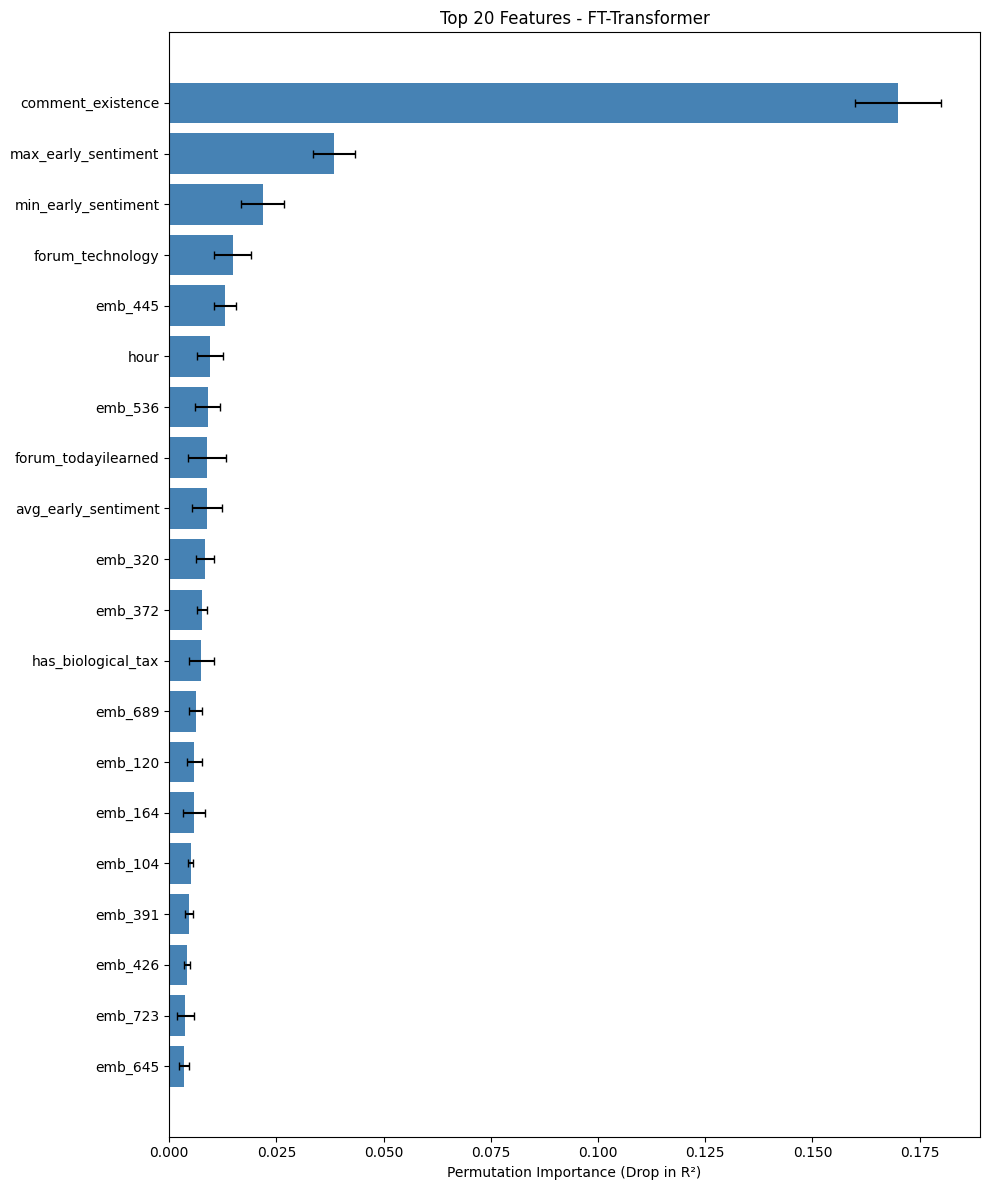


Feature importance completed.


In [ ]:
model = FTTransformer(
    n_cont_features=n_num_features,
    cat_cardinalities=None,
    d_out=d_out,
    **default_kwargs,
)
model.load_state_dict(best_model_state)   # best_model_state is on CPU
model = model.to(device)
model.eval()

# ==========================================
# 3. Wrap model for single‑tensor input
# ==========================================
class ModelWrapper(torch.nn.Module):
    def __init__(self, ft_model):
        super().__init__()
        self.ft_model = ft_model
    def forward(self, x_cont):
        return self.ft_model(x_cont, None)

wrapped_model = ModelWrapper(model).to(device)
wrapped_model.eval()

# ==========================================
# 4. Manual permutation importance (batched, GPU)
# ==========================================
def predict_batched(model_wrapper, X_numpy, batch_size=256):
    """Efficient GPU prediction with batching."""
    model_wrapper.eval()
    n = len(X_numpy)
    preds = np.empty(n, dtype=np.float32)
    with torch.no_grad():
        for start in range(0, n, batch_size):
            end = min(start + batch_size, n)
            X_batch = torch.tensor(X_numpy[start:end], dtype=torch.float32, device=device)
            with torch.cuda.amp.autocast():
                out = model_wrapper(X_batch).cpu().numpy().ravel()
            preds[start:end] = out
    return preds

def permutation_importance_gpu(model_wrapper, X, y, n_repeats=5, batch_size=256, random_state=42):
    """Manual permutation importance – loop over features, each with batched prediction."""
    rng = np.random.RandomState(random_state)
    # Baseline R²
    y_pred_base = predict_batched(model_wrapper, X, batch_size)
    base_r2 = r2_score(y, y_pred_base)
    print(f"Baseline R²: {base_r2:.4f}")

    n_features = X.shape[1]
    imp_mean = np.zeros(n_features)
    imp_std = np.zeros(n_features)

    for feat_idx in range(n_features):
        scores = []
        for _ in range(n_repeats):
            X_perm = X.copy()
            X_perm[:, feat_idx] = rng.permutation(X_perm[:, feat_idx])
            y_pred_perm = predict_batched(model_wrapper, X_perm, batch_size)
            r2_perm = r2_score(y, y_pred_perm)
            scores.append(base_r2 - r2_perm)   # drop in R²
        imp_mean[feat_idx] = np.mean(scores)
        imp_std[feat_idx] = np.std(scores)

        if (feat_idx + 1) % 50 == 0:
            print(f"Processed {feat_idx+1}/{n_features} features")

    return imp_mean, imp_std

# ==========================================
# 5. Prepare data (smaller subset to save time)
# ==========================================
sample_size = min(2000, len(X_val_tensor))   # adjust: 2000 is safe, 5000 if memory permits
indices = np.random.RandomState(RANDOM_STATE).choice(len(X_val_tensor), sample_size, replace=False)
X_val_sample = X_val_tensor[indices].cpu().numpy()   # keep on CPU for permutation
y_val_sample = y_val_tensor[indices].cpu().numpy().flatten()

print(f"Computing importance on {sample_size} samples, {X_val_sample.shape[1]} features...")

# ==========================================
# 6. Run permutation importance
# ==========================================
imp_means, imp_stds = permutation_importance_gpu(
    wrapped_model,
    X_val_sample,
    y_val_sample,
    n_repeats=5,          # can reduce to 3 for speed
    batch_size=256,       # GPU batch size during prediction
    random_state=RANDOM_STATE
)

# ==========================================
# 7. Results & plotting
# ==========================================
imp_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': imp_means,
    'StdDev': imp_stds
}).sort_values('Importance', ascending=False).head(20)

plt.figure(figsize=(10, 12))
plt.barh(imp_df['Feature'][::-1], imp_df['Importance'][::-1],
         xerr=imp_df['StdDev'][::-1], color='steelblue', capsize=3)
plt.xlabel('Permutation Importance (Drop in R²)')
plt.title('Top 20 Features - FT-Transformer')
plt.tight_layout()
plt.show()

print("\nFeature importance completed.")

In [ ]:
print(Xxxxxxxxxxxxxx)

NameError: name 'Xxxxxxxxxxxxxx' is not defined

In [ ]:
model_info = {
    'model_state_dict': {k: v.cpu() for k, v in best_model_state.items()},
    'model_config': {
        'n_cont_features': n_num_features,
        'cat_cardinalities': None,
        'd_out': d_out,
        'default_kwargs': default_kwargs,
    },
    'feature_names': list(X_train.columns),
    'device_info': str(device)
}
torch.save(model_info, 'ft_transformer_model.pth')
print("\nModel saved as 'ft_transformer_model.pth'")

results = {
    'r2_validation': val_r2_final,
    'r2_test': test_r2,
    'test_mse': test_loss,
    'device_used': str(device)
}
joblib.dump(results, 'ft_transformer_results.pkl')
print("Results saved as 'ft_transformer_results.pkl'")

# Final cleanup
if device.type == "cuda":
    torch.cuda.empty_cache()
    print(f"Final GPU memory allocated: {torch.cuda.memory_allocated(0)/1e9:.2f} GB")

print("\nTraining complete!")

In [ ]:
from sklearn.base import BaseEstimator, RegressorMixin

class TorchFTTransformerWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, model, device):
        self.model = model
        self.device = device

    def fit(self, X=None, y=None):
        """Dummy fit method to satisfy sklearn's estimator validation."""
        return self

    def predict(self, X):
        self.model.eval()
        with torch.no_grad():
            X_tensor = torch.tensor(X, dtype=torch.float32).to(self.device)
            with autocast():
                preds = self.model(X_tensor, None).cpu().numpy()
        return preds.ravel()  # ensure 1D


cpu_model = FTTransformer(
    n_cont_features=n_num_features,
    cat_cardinalities=None,
    d_out=d_out,
    **default_kwargs,
)
cpu_model.load_state_dict({k: v.cpu() for k, v in best_model_state.items()})
cpu_model = cpu_model.to('cpu')
cpu_model.eval()

# Use CPU version
wrapper = TorchFTTransformerWrapper(cpu_model, 'cpu')
result = permutation_importance(
    wrapper, X_val_sample, y_val_sample,
    n_repeats=3,  # reduce repeats
    scoring='r2',
    random_state=RANDOM_STATE,
    n_jobs=-1
)